Our Hypothesis is, as a result of the digital exposure control on the SBIG AllSky-340, that the integration / exposure time alone will not be sufficient to draw conclusions.

In [1]:
import pandas as pd
from pathlib import Path

files = sorted(Path().glob("../../data/20*-*.parquet"))
files

[PosixPath('../../data/2010-08.parquet'),
 PosixPath('../../data/2010-09.parquet'),
 PosixPath('../../data/2010-10.parquet'),
 PosixPath('../../data/2010-11.parquet'),
 PosixPath('../../data/2010-12.parquet'),
 PosixPath('../../data/2011-01.parquet'),
 PosixPath('../../data/2011-02.parquet'),
 PosixPath('../../data/2011-03.parquet'),
 PosixPath('../../data/2011-04.parquet'),
 PosixPath('../../data/2011-05.parquet'),
 PosixPath('../../data/2011-06.parquet'),
 PosixPath('../../data/2011-07.parquet'),
 PosixPath('../../data/2011-08.parquet'),
 PosixPath('../../data/2011-09.parquet'),
 PosixPath('../../data/2011-10.parquet'),
 PosixPath('../../data/2011-11.parquet'),
 PosixPath('../../data/2011-12.parquet'),
 PosixPath('../../data/2012-01.parquet'),
 PosixPath('../../data/2012-02.parquet'),
 PosixPath('../../data/2012-03.parquet'),
 PosixPath('../../data/2012-04.parquet'),
 PosixPath('../../data/2012-05.parquet'),
 PosixPath('../../data/2012-06.parquet'),
 PosixPath('../../data/2012-07.par

In [2]:
from dask import dataframe as dd

df: dd.DataFrame = dd.read_parquet(files)
df.describe

<bound method DataFrame.describe of Dask DataFrame Structure:
                   date    time exposure filename
npartitions=176                                  
                 string  string   string   string
                    ...     ...      ...      ...
...                 ...     ...      ...      ...
                    ...     ...      ...      ...
                    ...     ...      ...      ...
Dask Name: read_parquet, 1 expression
Expr=ReadParquetFSSpec(aa86532)>

In [3]:
df.compute()

,date,time,exposure,filename
0,2010/08/11,19:16:0?,0.0000,000021138
1,2010/08/11,19:17:09,0.0000,000021139
2,2010/08/11,19:24:05,0.0000,000021140
3,2010/08/11,19:25:05,0.0000,000021141
4,2010/08/11,19:26:05,0.0000,000021142
...,...,...,...,...
18,2026/03/26,22:37:50,9.3215,000425553
19,2026/03/26,22:38:49,9.3215,000425554
20,2026/03/26,22:43:56,9.3215,000425555
21,2026/03/26,22:45:20,3.3501,000425556


In [4]:
from allsky.validation import is_valid_record_series

invalid_rows = ~is_valid_record_series(df)
df[invalid_rows].compute()

,date,time,exposure,filename
0,2010/08/11,19:16:0?,0.0000,000021138
28,2010/0?/13,19:16:0?,0.0000,000021486
5,2010/08/1?,19:29:18,0.0000,000021495
13,???0/08/?5,2?:36:16,0.0011,000022367
12,2010/0?/16,19:23:4?,0.0000,000022718
...,...,...,...,...
3,????/??/??,15:09:40,0.0000,000416864
29,2?2?/?3/23,19:26:29,0.0008,000419195
18,2026/?3/26,21:23:38,4.9161,000425521
10,2?26/03/2?,22:16:29,7.3849,000425545


In [5]:
df[~invalid_rows].compute()

,date,time,exposure,filename
1,2010/08/11,19:17:09,0.0000,000021139
2,2010/08/11,19:24:05,0.0000,000021140
3,2010/08/11,19:25:05,0.0000,000021141
4,2010/08/11,19:26:05,0.0000,000021142
5,2010/08/11,19:27:06,0.0000,000021143
...,...,...,...,...
18,2026/03/26,22:37:50,9.3215,000425553
19,2026/03/26,22:38:49,9.3215,000425554
20,2026/03/26,22:43:56,9.3215,000425555
21,2026/03/26,22:45:20,3.3501,000425556


Now I need to figure out what these 2,856,868 rows actually tell us.

1. Form datetimes from the timestamps
2. Plot the exposure against the timestamps

In [6]:
df = df[~invalid_rows]
df = df.assign(
    timestamp=dd.to_datetime(df["date"] + " " + df["time"], format="%Y/%m/%d %H:%M:%S")
)
df = df.assign(exposure=df["exposure"].astype(float))
df.head()

,date,time,exposure,filename,timestamp
1,2010/08/11,19:17:09,0.0,000021139,2010-08-11 19:17:09
2,2010/08/11,19:24:05,0.0,000021140,2010-08-11 19:24:05
3,2010/08/11,19:25:05,0.0,000021141,2010-08-11 19:25:05
4,2010/08/11,19:26:05,0.0,000021142,2010-08-11 19:26:05
5,2010/08/11,19:27:06,0.0,000021143,2010-08-11 19:27:06


In [7]:
df = df.compute()
df

,date,time,exposure,filename,timestamp
1,2010/08/11,19:17:09,0.0000,000021139,2010-08-11 19:17:09
2,2010/08/11,19:24:05,0.0000,000021140,2010-08-11 19:24:05
3,2010/08/11,19:25:05,0.0000,000021141,2010-08-11 19:25:05
4,2010/08/11,19:26:05,0.0000,000021142,2010-08-11 19:26:05
5,2010/08/11,19:27:06,0.0000,000021143,2010-08-11 19:27:06
...,...,...,...,...,...
18,2026/03/26,22:37:50,9.3215,000425553,2026-03-26 22:37:50
19,2026/03/26,22:38:49,9.3215,000425554,2026-03-26 22:38:49
20,2026/03/26,22:43:56,9.3215,000425555,2026-03-26 22:43:56
21,2026/03/26,22:45:20,3.3501,000425556,2026-03-26 22:45:20


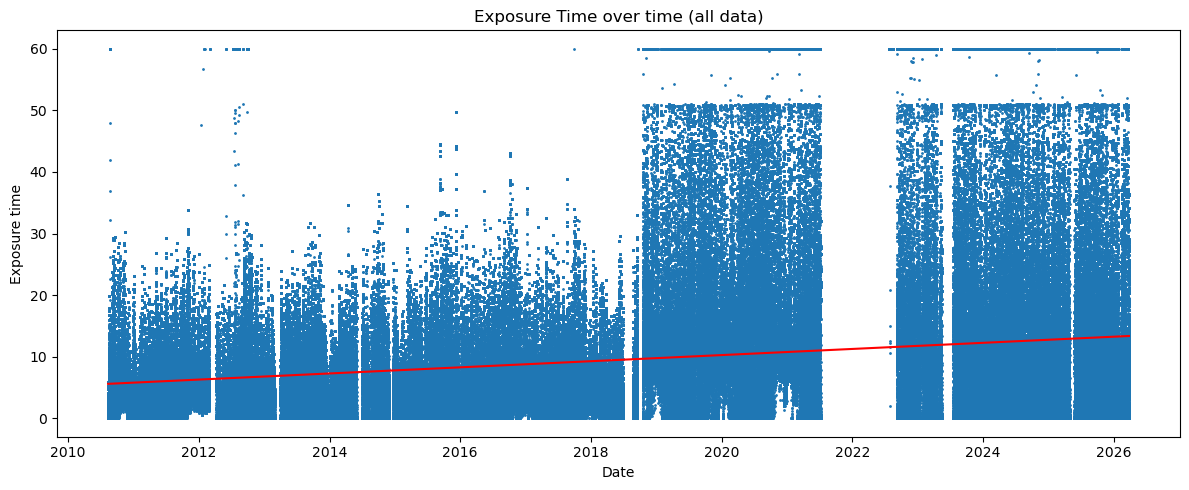

In [8]:
import numpy as np
from matplotlib import pyplot as plt

a: pd.DataFrame = df[["timestamp", "exposure"]]

plot_df = a.dropna(subset=["timestamp", "exposure"]).sort_values("timestamp").copy()
x = plot_df["timestamp"]
y = plot_df["exposure"].to_numpy()

ord_x = x.map(pd.Timestamp.toordinal).to_numpy()

slope, intercept = np.polyfit(ord_x, y, 1)
y_fit = slope * ord_x + intercept

plt.figure(figsize=(12, 5))
plt.scatter(x, y, s=1)
plt.plot(x, y_fit, color="red")
plt.title("Exposure Time over time (all data)")
plt.xlabel("Time")
plt.ylabel("Exposure")
plt.xlabel("Date")
plt.ylabel("Exposure time")
plt.tight_layout()

It's evident all the cloudy and glitched observation images makes a regression line kind of impossible to do correctly

In [9]:
b = a.loc[~a["timestamp"].dt.hour.between(6, 20)].copy()
b = b.loc[b["exposure"] < 50.0]
b

,timestamp,exposure
11,2010-08-11 21:00:00,0.0836
12,2010-08-11 21:03:56,0.1966
13,2010-08-11 21:06:02,0.4776
14,2010-08-11 21:07:10,0.7904
15,2010-08-11 21:09:07,1.0218
...,...,...
18,2026-03-26 22:37:50,9.3215
19,2026-03-26 22:38:49,9.3215
20,2026-03-26 22:43:56,9.3215
21,2026-03-26 22:45:20,3.3501


In [10]:
plot_df = b.dropna(subset=["timestamp", "exposure"]).sort_values("timestamp").copy()
x = plot_df["timestamp"].map(pd.Timestamp.toordinal).to_numpy()
y = plot_df["exposure"].to_numpy()

slope, intercept = np.polyfit(x, y, 1)
slope

np.float64(0.0021226845624228875)

From here the exploration takes a sharp turn, and I began to look at the ephemera as they get applied directly to the input data. Particularly studying the ephemera for each timestamp referenced.

In [11]:
from allsky.astronomy import (
    get_times_from_dataframe,
    get_moon_phase,
    get_altaz,
    sun,
    moon,
    ASTRONOMICAL_TWILIGHT,
    NEWMOON_LIGHT_FRACTION,
)

times = get_times_from_dataframe(df)

[#################################] 100% de405.bsp


In [12]:
sun_alt, _ = get_altaz(sun, times)
moon_alt, _ = get_altaz(moon, times)

sun_alt, moon_alt

(array([ 11.22487166,   9.9290376 ,   9.74253194, ..., -33.34500366,
        -33.55056635, -33.67001403], shape=(2856868,)),
 array([18.90451793, 17.64943829, 17.46790827, ..., 60.51236192,
        60.27075575, 60.12951202], shape=(2856868,)))

In [13]:
moonlit = get_moon_phase(times)
moonlit

array([0.05205806, 0.05229125, 0.05232509, ..., 0.6443312 , 0.64440571,
       0.64444923], shape=(2856868,))

In [14]:
# have to gather all the conditions together
# (i.e. if I iteratively cut the data down, then I'll lose the row-to-row relation with `times`)
sundown_condition = sun_alt < ASTRONOMICAL_TWILIGHT
moondown_condition = moon_alt < ASTRONOMICAL_TWILIGHT
newmoon_condition = moonlit < NEWMOON_LIGHT_FRACTION

(
    np.sum(sundown_condition),
    np.sum(moondown_condition),
    np.sum(sundown_condition & newmoon_condition & ~moondown_condition),
)

(np.int64(1546538), np.int64(1025350), np.int64(19173))

In [15]:
np.sum(sundown_condition & (moondown_condition | newmoon_condition))

np.int64(581805)

In [16]:
ideal_df = df[sundown_condition & (moondown_condition | newmoon_condition)]
ideal_df

,date,time,exposure,filename,timestamp
8,2010/08/11,22:38:00,2.7883,000021274,2010-08-11 22:38:00
9,2010/08/11,22:39:17,2.4769,000021275,2010-08-11 22:39:17
10,2010/08/11,22:40:17,2.4769,000021276,2010-08-11 22:40:17
11,2010/08/11,22:41:34,2.4769,000021277,2010-08-11 22:41:34
12,2010/08/11,22:42:34,2.4769,000021278,2010-08-11 22:42:34
...,...,...,...,...,...
4,2026/03/25,05:40:08,32.0241,000422467,2026-03-25 05:40:08
5,2026/03/25,05:40:41,32.0241,000422468,2026-03-25 05:40:41
6,2026/03/25,05:41:34,36.3559,000422469,2026-03-25 05:41:34
7,2026/03/25,05:42:11,36.3559,000422470,2026-03-25 05:42:11


In [17]:
from allsky.analysis import quick_exposure_linregress

quick_exposure_linregress(ideal_df[ideal_df["exposure"] < 50.0])

(np.float64(0.0018026984386410275), np.float64(-1316.1800432779248))